# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [12]:
df = pd.read_csv("/content/MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv")

df.describe()

,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto
count,1107.000000,1107.000000,1107.000000,1107.000000
mean,2070.997290,522.269196,372.257453,68.109304
std,2961.257627,1339.559852,1239.475017,241.158310
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1269.000000,0.000000,0.000000,0.000000
75%,2849.000000,0.000000,0.000000,0.000000
max,19788.000000,14550.000000,18899.000000,4349.000000


In [13]:
df.shape

(1107, 7)

Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [22]:
media_categoria = df.groupby('Categoria')['Preco_Normal'].mean()
print(media_categoria)


Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64


In [15]:
mediana_categoria = df.groupby('Categoria')['Preco_Normal'].median()
print(mediana_categoria)


Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64


- As categorias em que a média está acima da mediana são: belleza-y-cuidado-personal, congelados, frutas, instantaneos-y-sopas, lacteos e verduras.

- A categoria em que a média está abaixo da mediana é comidas-preparadas.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [16]:
desvio_categoria = df.groupby('Categoria')['Preco_Normal'].std()
print(desvio_categoria)


Categoria
belleza-y-cuidado-personal    2210.041719
comidas-preparadas            2019.911428
congelados                    2111.539896
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
lacteos                       3925.816164
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


- As categorias com maior desvio padrão, como lacteos, belleza-y-cuidado-personal e congelados, apresentam maior variação nos preços. Nessas categorias, observa-se que a média é maior que a mediana, indicando a presença de valores extremos (produtos muito caros) que aumentam a média. Já a mediana permanece mais estável, pois representa o valor central da distribuição.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

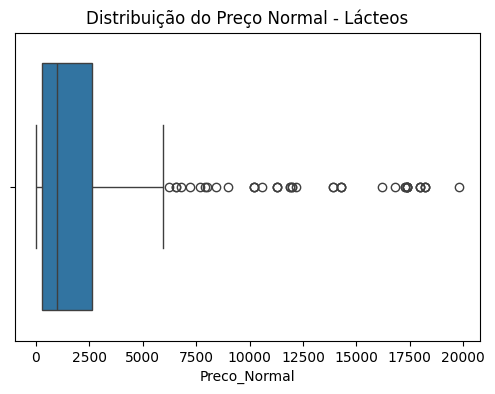

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar apenas a categoria lacteos
df_lacteos = df.loc[df['Categoria'] == 'lacteos']

# Criar o boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df_lacteos['Preco_Normal'])

plt.title('Distribuição do Preço Normal - Lácteos')
plt.xlabel('Preco_Normal')

plt.show()


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

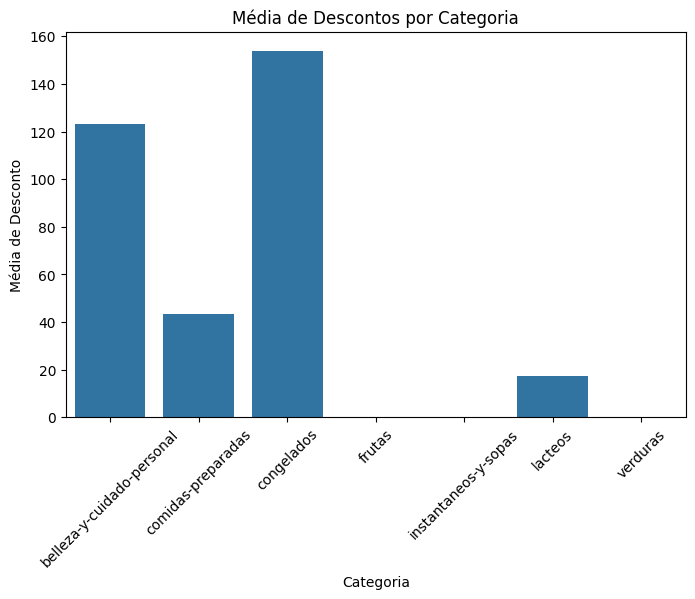

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# calcular média de desconto por categoria
media_desconto = df.groupby('Categoria')['Desconto'].mean().reset_index()

# gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(data=media_desconto, x='Categoria', y='Desconto')

plt.title('Média de Descontos por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')

plt.xticks(rotation=45)
plt.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [21]:
import plotly.express as px

# Agrupar dados
tabela = df.groupby(['Categoria','Marca'])['Desconto'].mean().reset_index()

# Criar heatmap interativo
fig = px.density_heatmap(
    tabela,
    x='Marca',
    y='Categoria',
    z='Desconto',
    color_continuous_scale='Viridis',
    title='Média de Desconto por Categoria e Marca'
)

fig.show()